## Heatmap for Platform Beds by Years

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df =pd.read_csv("review-vc_sales_by_collection.csv")

In [5]:
df

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty
0,202201,Box Springs,__TOTAL__,4.115207,77.0,434.0,0.177419,NaN,NaN,NaN,NaN,6916730.26,50316.0
1,202201,Box Springs,Walter 9in,3.500000,3.0,8.0,0.375000,NaN,NaN,NaN,NaN,91988.82,446.0
2,202201,Box Springs,Walter 7.5in,4.500000,1.0,10.0,0.100000,NaN,NaN,NaN,NaN,271300.75,1670.0
3,202201,Box Springs,Walter 4in,4.666667,1.0,9.0,0.111111,NaN,NaN,NaN,NaN,229874.12,1231.0
4,202201,Box Springs,Victor 9in,5.000000,0.0,2.0,0.000000,NaN,NaN,NaN,NaN,60917.50,297.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23388,202503,Toppers,1.5in GTFT w WonderBox,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,4739.44,117.0
23389,202503,Toppers,1.5in GT MF,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2635.14,73.0
23390,202503,Toppers,1.5in Copper Convoluted,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
23391,202503,Toppers,1.25in Swirl Copper,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,67.94,1.0


In [13]:
df['year'] = df['yr_month'].astype(str).str[:4]

In [15]:
platform_df = df[
    (df['financial_category']=='Platform Beds') &
    (df['year'].isin(['2022','2023','2024']))
].copy()

In [17]:
platform_df = platform_df[platform_df['collection'] != '__TOTAL__']

In [19]:
platform_df = platform_df.dropna(subset=['written_avg_rating'])

In [21]:
platform_df

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,year
165,202201,Platform Beds,Yelena 18in,5.000000,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,3035.52,19.0,2022
166,202201,Platform Beds,Yelena 14in,4.379310,3.0,29.0,0.103448,NaN,NaN,NaN,NaN,228758.43,1988.0,2022
167,202201,Platform Beds,Wesley Canopy,4.000000,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,1559.23,5.0,2022
169,202201,Platform Beds,Wen Deluxe w HB,2.000000,1.0,1.0,1.000000,NaN,NaN,NaN,NaN,12399.61,43.0,2022
170,202201,Platform Beds,Wen Deluxe,4.550000,2.0,20.0,0.100000,NaN,NaN,NaN,NaN,152874.52,769.0,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21155,202412,Platform Beds,Alexis Deluxe w HB,4.000000,1.0,3.0,0.333333,4.000000,1.0,3.0,0.333333,61435.74,223.0,2024
21156,202412,Platform Beds,Alexis Deluxe,5.000000,0.0,1.0,0.000000,5.000000,0.0,1.0,0.000000,48365.88,302.0,2024
21158,202412,Platform Beds,Alexia,3.250000,1.0,4.0,0.250000,3.250000,1.0,4.0,0.250000,26629.39,177.0,2024
21160,202412,Platform Beds,Adrian,3.666667,1.0,3.0,0.333333,3.666667,1.0,3.0,0.333333,5474.48,25.0,2024


In [29]:
top_cols = (
    platform_df.groupby('collection')['sales_amount']
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .index
)

In [31]:
top_cols

Index(['Abel', 'Van 16in', 'Shalini', 'Mia 1500H', 'Lorelai 14in',
       'Alexia w HB', 'Dachelle', 'Vivek Deluxe w HB', 'Tonja', 'Lottie',
       'Curtis', 'Yelena 14in', 'Alexis Deluxe', 'Moiz', 'Lorelei 12in', 'Kai',
       'Suzanne HB', 'Tricia', 'Allen', 'Korey', 'Misty, Taupe', 'Mia 1500',
       'Omkaram', 'Judy', 'Vivek w HB', 'Wen Deluxe', 'Joseph 10in',
       'Shalini, Light Grey', 'Marissa Deluxe', 'Alexis Deluxe w HB'],
      dtype='object', name='collection')

In [35]:
platform_cols = platform_df[platform_df['collection'].isin(top_cols)].copy()

In [37]:
platform_cols['rating_bin'] = platform_cols['written_avg_rating'].round(1)

In [39]:
platform_cols

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,year,rating_bin
166,202201,Platform Beds,Yelena 14in,4.379310,3.0,29.0,0.103448,NaN,NaN,NaN,NaN,228758.43,1988.0,2022,4.4
170,202201,Platform Beds,Wen Deluxe,4.550000,2.0,20.0,0.100000,NaN,NaN,NaN,NaN,152874.52,769.0,2022,4.6
172,202201,Platform Beds,Vivek w HB,4.583333,0.0,12.0,0.000000,NaN,NaN,NaN,NaN,102899.87,404.0,2022,4.6
173,202201,Platform Beds,Vivek Deluxe w HB,4.720000,1.0,25.0,0.040000,NaN,NaN,NaN,NaN,415457.76,1563.0,2022,4.7
174,202201,Platform Beds,Van 16in,4.186047,14.0,86.0,0.162791,NaN,NaN,NaN,NaN,692922.46,6080.0,2022,4.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21122,202412,Platform Beds,Curtis,4.545455,0.0,11.0,0.000000,4.545455,0.0,11.0,0.000000,112890.31,1717.0,2024,4.5
21154,202412,Platform Beds,Allen,4.200000,1.0,5.0,0.200000,4.200000,1.0,5.0,0.200000,157309.01,491.0,2024,4.2
21155,202412,Platform Beds,Alexis Deluxe w HB,4.000000,1.0,3.0,0.333333,4.000000,1.0,3.0,0.333333,61435.74,223.0,2024,4.0
21156,202412,Platform Beds,Alexis Deluxe,5.000000,0.0,1.0,0.000000,5.000000,0.0,1.0,0.000000,48365.88,302.0,2024,5.0


In [41]:
rating_bins = np.round(np.arange(0.1,5.1,0.1),1)

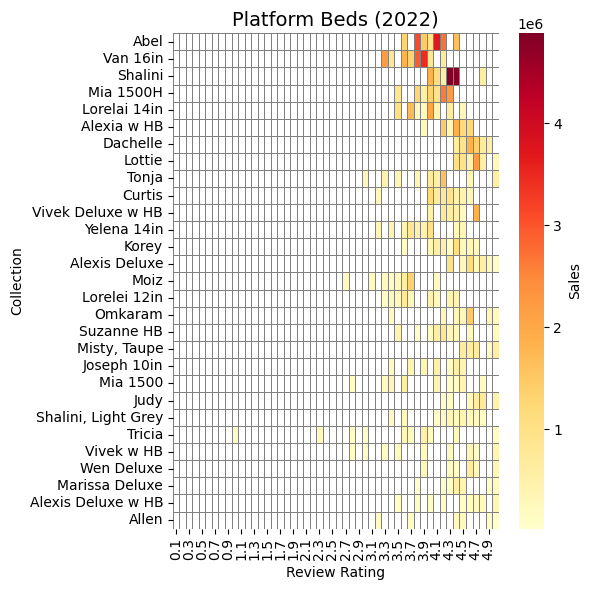

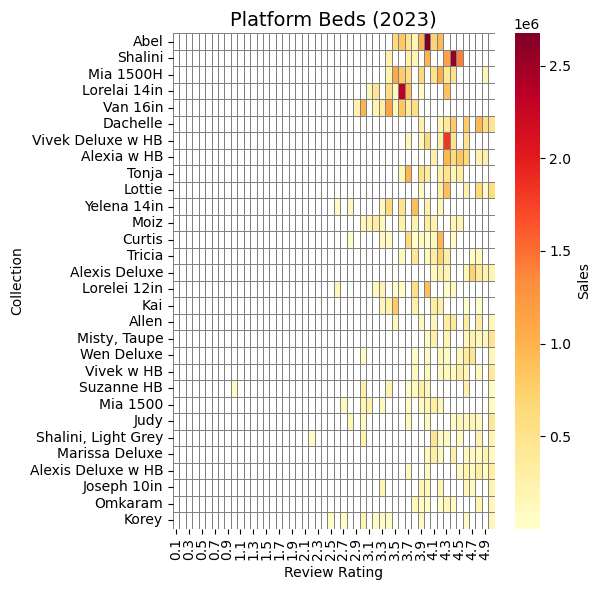

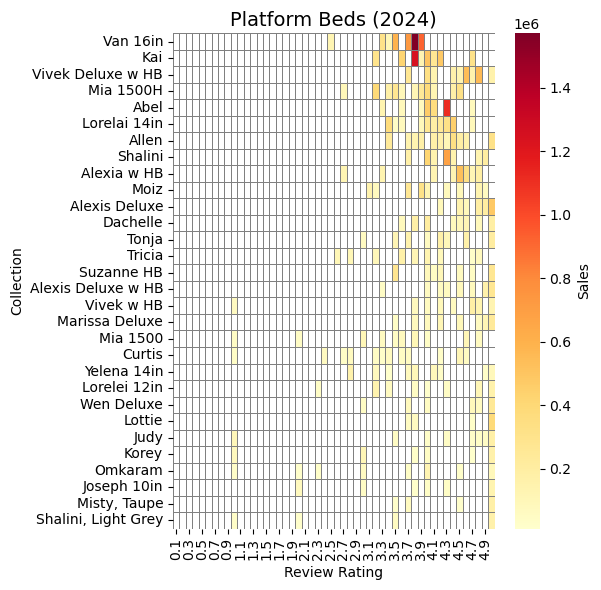

In [58]:
for year in ['2022','2023','2024']:
    pivot = (
        platform_cols[platform_cols['year']==year]
        .groupby(['collection','rating_bin'])['sales_amount']
        .sum()
        .unstack(fill_value=0)
       # .sort_index()
    )

    #누락 평점 구간을 포함시키고 정렬
    pivot = pivot.reindex(columns=rating_bins, fill_value=0)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    # 힌색으로 마스킹 하기
    mask = pivot == 0
    
    plt.figure(figsize=(6,6))
    sns.heatmap(pivot, cmap='YlOrRd', mask=mask, linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Sales'}, square=False)
                                                                                  
    plt.title(f'Platform Beds ({year})', fontsize=14)
    plt.xlabel('Review Rating')
    plt.ylabel('Collection')
    plt.tight_layout()
    plt.show()
    